In [2]:
import sys
sys.path.append('..')

from models.compression.vq_vae import VQVAE
from dataset import ImageCompressionDataModule

In [3]:
device = "cpu"

model = VQVAE(
    h_dim=256,
    n_embeddings=1024,
    embedding_dim=64,
    beta=0.25,
    lr=1e-3,
    n_heads=4,
    n_layers=3,
    patch_size=1,
    freeze_encoder=False,  # Freeze encoder (random initialization)
    freeze_decoder=False,  # Freeze decoder (random initialization)
    freeze_quantizer=False,  # Train quantizer only
    gradient_descent_quantizer=True,
    load_params=["encoder", "decoder", "vector_quantization"],
    load_path="../../checkpoints/stage1/vq_vae_quantizer_pretrain-v4.ckpt",
)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Loading components ['encoder', 'decoder', 'vector_quantization'] from ../../checkpoints/stage1/vq_vae_quantizer_pretrain-v4.ckpt
Loaded 97 parameters for encoder
Loaded 65 parameters for decoder
Loaded 8 parameters for vector_quantization
VQVAE __init__ complete.


In [4]:
dataset = ImageCompressionDataModule(
    data_dir="../../data/PetImages",
    batch_size=1,
)

dataset=dataset.setup()

In [5]:
for batch in dataset.train_dataloader():
    imgs, _ = batch
    imgs = imgs.to(device)
    _, recons, latents, _ = model(imgs)
    print("Input images shape:", imgs.shape)
    print("Reconstructed images shape:", recons.shape)
    print("Latent indices shape:", latents.shape)
    break

Input images shape: torch.Size([1, 3, 448, 448])
Reconstructed images shape: torch.Size([1, 3, 448, 448])
Latent indices shape: torch.Size([1, 3136, 4])


In [6]:
import torch
import numpy as np
import zstandard as zstd

BITS = 11  # for 0–1024


def pack_bits(latents: torch.Tensor, bits_per_value=BITS):
    x = latents.cpu().numpy().astype(np.uint64).reshape(-1)
    out = []
    buf = np.uint64(0)
    bits_in_buf = 0

    for v in x:
        buf |= (v << bits_in_buf)
        bits_in_buf += bits_per_value

        # flush full bytes
        while bits_in_buf >= 8:
            out.append(int(buf & 0xFF))
            buf >>= 8
            bits_in_buf -= 8

    # flush remaining bits
    if bits_in_buf > 0:
        out.append(int(buf & 0xFF))

    return bytes(out), x.size


def unpack_bits(packed: bytes, count: int, bits_per_value=BITS):
    data = np.frombuffer(packed, dtype=np.uint8)
    out = np.zeros(count, dtype=np.uint64)

    buf = np.uint64(0)
    bits_in_buf = 0
    byte_i = 0

    for idx in range(count):
        # ensure enough bits for one value
        while bits_in_buf < bits_per_value:
            buf |= np.uint64(data[byte_i]) << bits_in_buf
            bits_in_buf += 8
            byte_i += 1

        # extract value
        v = buf & ((1 << bits_per_value) - 1)
        out[idx] = v

        # remove consumed bits
        buf >>= bits_per_value
        bits_in_buf -= bits_per_value

    return torch.from_numpy(out.astype(np.int32).reshape(1, 3136, 4))


packed_raw, count = pack_bits(latents)

compressed = zstd.ZstdCompressor(level=19).compress(packed_raw)

raw = zstd.ZstdDecompressor().decompress(compressed)
restored = unpack_bits(raw, count)

print(torch.equal(restored, latents)) 


True


In [7]:
original_size = latents.numel() * 4  # 4 bytes per int32
packed_size = len(packed_raw)
compressed_size = len(compressed)

print(f"Original size (int32): {original_size:,} bytes")
print(f"Packed size ({BITS}-bit): {packed_size:,} bytes")
print(f"Compressed size (zstd): {compressed_size:,} bytes")
print(f"Compression ratio: {original_size / compressed_size:.2f}x")
print(f"Bits per latent: {(compressed_size * 8) / latents.numel():.2f}")

Original size (int32): 50,176 bytes
Packed size (11-bit): 17,248 bytes
Compressed size (zstd): 17,102 bytes
Compression ratio: 2.93x
Bits per latent: 10.91


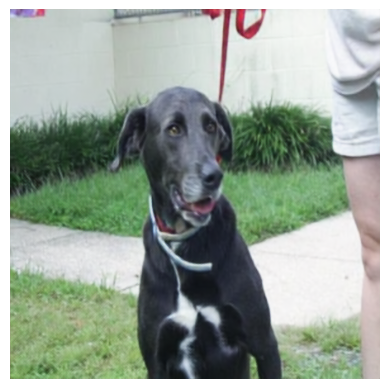

In [8]:
restored = restored.to(torch.int64)

import matplotlib.pyplot as plt

recons_from_restored = model.forward_with_latents(latents)

if isinstance(recons_from_restored, tuple):
    recons_from_restored = recons_from_restored[0]

img = recons_from_restored.squeeze().cpu().detach().numpy()

if img.shape[0] == 3:
    img = img.transpose(1, 2, 0)

plt.imshow((img + 1) / 2) 
plt.axis('off')
plt.show()